[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syaikhipin/kdd26-memdiag/blob/tutorial-rebuild/tutorial/phase4_cognitive_memory/11_cognitive_constraint_layer.ipynb)

> **Run this notebook in Google Colab** — click the badge above. The setup cell auto-clones the repo.
> **Phase 4 core (Steps 1-4) is fully offline - no API key needed.** An optional **live-LLM payoff
> demo** (Step 2b) runs if you set a key in the config cell; it degrades to a note if none.


# 11. Cognitive Memory Layer (CML) — constraint-aware memory

Phase 4 hands-on. Phases 1–3 worked with **storage** memories (verbatim, episodic,
extracted_facts, hybrid): they retrieve by lexical similarity. Here we build a tiny
“CML-lite” provider that adds the one thing none of them have — **constraint
awareness**: the ability to surface a stored rule (“I’m allergic to shellfish”,
“depth 16 → OOM”) even when the query has zero word overlap.

This mirrors the key differentiator of the real [Cognitive Memory Layer]
(https://github.com/avinash-mall/CognitiveMemoryLayer), a neuro-inspired architecture
(Docker + Postgres + Neo4j + Redis + ~25 GB of models) we cannot run in a Colab slot.
We capture its cognitive core in ~90 lines of pure Python and diagnose it with the
same 3-probe / LoCoMo harness from Phases 2–3 — the tutorial’s low-resource ethos.

## The 5 cognitive constraint types

| Type | Example | When the cognitive layer surfaces it |
|---|---|---|
| POLICY | “I’m allergic to shellfish” | always (safety-critical) |
| STATE | “the GPU server is down” | always |
| CAUSAL | “depth 16 batch 32 → OOM” | action / config queries (Phase 3!) |
| GOAL | “I want to lose weight” | recommendation queries |
| VALUE | “I value privacy over convenience” | recommendation queries |

**What CML-lite omits vs. the real CML** (we read this honestly at the end):
- 15 memory types & biological decay profiles → we keep a single `constraint_type` tag
- reconsolidation (REINFORCE / TIME_SLICE / MERGE / ADD_HYPOTHESIS) → none
- consolidation (episodes → semantic gist) → none
- active-forgetting triage (keep / decay / silence / compress / delete) → none
- multi-path retrieval (vector + knowledge-graph PageRank + rescoring) → lexical + constraint injection

In [ ]:
# Self-contained setup - works standalone in Google Colab or locally.
# Phase 4 (Cognitive Memory Layer) CORE is offline; an optional live-LLM "payoff" demo (Step 2b)
# uses the openai client if you set a key in the config cell.
# Self-contained setup - works standalone in Google Colab or locally.
import sys, os, subprocess
from pathlib import Path
REPO_URL = "https://github.com/syaikhipin/kdd26-memdiag"
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    repo = Path("/content/kdd26-memdiag")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "tutorial-rebuild", REPO_URL, str(repo)], check=False)
    SOURCE = repo / "source"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "matplotlib", "pyyaml", "openai"], check=False)
else:
    SOURCE = None
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("source", "experiment"):
            if (cand / sub / "run.py").exists():
                SOURCE = cand / sub
                break
        if SOURCE:
            break
    if SOURCE is None:
        raise FileNotFoundError("Run from the repo root (or in Colab it auto-clones).")
sys.path.insert(0, str(SOURCE))
SOURCE_DIR = SOURCE
PROJECT_ROOT = SOURCE.parent
RESULTS_DIR = PROJECT_ROOT / "results"
try: _d = "<repo>/" + str(Path(SOURCE).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d, "| found =", True, "| IN_COLAB =", IN_COLAB)

## ⚙️ LLM endpoint config — base URL · API key · model
Phase 4's **core** (Steps 1-4: constraint extraction, the cognitive read path, the 3-probe
diagnostic) is **fully offline** — it never calls the LLM, so no API key is required for it.
This cell loads the config you saved in Phases 1-3 (a local file, or Google Drive in Colab if
already mounted) and **builds a live `llm` client** for the optional **payoff demo** in Step 2b.
With no key, `llm` is the offline client and that demo degrades to a note. To (re)configure your
endpoint, use the prompt cell in any Phase 1-3 notebook — saved once, reused everywhere.


In [ ]:
# === LLM endpoint config (base URL / API key / model) ===
# Phase 4 CORE is offline; we read the config the Phase 1-3 prompt cell saved (no prompt here),
# and build a live `llm` for the optional payoff demo. No key -> OfflineLLMClient.
from config import setup_llm
OPENAI_BASE_URL, OPENAI_API_KEY, OPENAI_MODEL = setup_llm(prompt=False)
from llm_client import LLMConfig, make_client
llm = make_client(LLMConfig(backend="openai-compatible" if OPENAI_API_KEY else "offline",
                            base_url=OPENAI_BASE_URL, model=OPENAI_MODEL))


## Step 1 — write memories and extract constraints

`classify_constraint(text)` is the **write-time extractor** (CML’s regex mode; the real
system uses one LLM call per chunk). `CognitiveConstraintStrategy.write(content)` mirrors
the real CML SDK (`memory.write(content=..., tenant_id=...)`).

In [3]:
from strategies import ALL_STRATEGIES
from strategies.cognitive_constraint import classify_constraint

print("Registered providers:", sorted(ALL_STRATEGIES))
print()

samples = [
    "Patient profile: I am deathly allergic to shellfish.",
    "Dietary note: I am vegetarian.",
    "Infrastructure: the GPU server is down right now.",
    "Experiment log: running depth 16 batch 32 caused a CUDA OOM.",
    "User goal: I want to lose weight before summer.",
    "Preference: I value privacy over convenience.",
]
for s in samples:
    print(f"  {classify_constraint(s)!s:8s}  <-  {s}")

Registered providers: ['cognitive_constraint', 'episodic', 'extracted_facts', 'hybrid', 'no_memory', 'verbatim']

  POLICY    <-  Patient profile: I am deathly allergic to shellfish.
  POLICY    <-  Dietary note: I am vegetarian.
  STATE     <-  Infrastructure: the GPU server is down right now.
  CAUSAL    <-  Experiment log: running depth 16 batch 32 caused a CUDA OOM.
  GOAL      <-  User goal: I want to lose weight before summer.
  VALUE     <-  Preference: I value privacy over convenience.


## Step 2 — the cognitive read path beats plain RAG on zero overlap

Store the shellfish allergy, then ask **“recommend a restaurant”**. The cosine overlap
between `allergic/shellfish` and `recommend/restaurant` is ~0, so a plain lexical store
(verbatim) retrieves nothing. CML-lite’s read path **injects the relevant POLICY
constraint regardless of overlap**. This is exactly the case where standard RAG fails
but cognitive memory succeeds.

In [4]:
from strategies import VerbatimStrategy, CognitiveConstraintStrategy

query = "recommend a restaurant for dinner"

# Plain lexical (verbatim): cosine only -> misses the allergy
v = VerbatimStrategy()
v.store.add("Patient profile: I am deathly allergic to shellfish.", entry_type="verbatim")
v_res = v.store.retrieve(query, top_k=5)[0]

# Cognitive: cosine + constraint injection -> surfaces the allergy
c = CognitiveConstraintStrategy()
c.write("Patient profile: I am deathly allergic to shellfish.")
c_res = c.read(query, top_k=5)[0]

print(f"Query: {query!r}")
print("verbatim            : ", [r["entry"].content[:40] for r in v_res] or "NOTHING RETRIEVED")
print("cognitive_constraint: ", [r["entry"].content[:40] for r in c_res])

Query: 'recommend a restaurant for dinner'
verbatim            :  NOTHING RETRIEVED
cognitive_constraint:  ['Patient profile: I am deathly allergic t']


## 🧠 Step 2b — the payoff: a live LLM acts on the surfaced constraint

Step 2 proved the cognitive layer **surfaces** the shellfish-allergy that lexical retrieval
misses. But the point of memory is **action, not storage**: hand that surfaced constraint to the
live LLM as context and watch its recommendation change.

- **without** the constraint (plain RAG) → the LLM has no way to know about the allergy (**unsafe**)
- **with** the surfaced constraint (cognitive memory) → the LLM steers clear (**safe**)

That is the end-to-end payoff: constraint-aware retrieval changes what the agent *does*.
*(Needs a key in the config cell; runs offline-safe if none — the Steps 1-4 core needs no key.)*


In [5]:
# === Step 2b: the payoff - a live LLM ACTS on the surfaced constraint ===
# Step 2 surfaced the shellfish-allergy that lexical retrieval misses. The point of memory is
# ACTION, not storage: hand that surfaced constraint to the LLM and watch the recommendation
# change. (Offline-safe: no API key -> `llm` is the OfflineLLMClient; this prints a note.)

# the constraint the cognitive read path surfaced for "recommend a restaurant":
surfaced = [r["entry"].content for r in c_res]          # from Step 2
ctx = "\n".join(f"  - {s}" for s in surfaced) or "  (none surfaced)"
print("Constraint surfaced by cognitive_constraint:", "\n" + ctx, "\n")

sysmsg = "You are a concise dining assistant. Recommend exactly one dish, in one sentence."
question = "Recommend ONE specific dinner dish. The chef is famous for seafood."
prompt_unsafe = question                                   # plain RAG: no user facts
prompt_safe   = f"Known facts about the user:\n{ctx}\n\n{question}"   # cognitive: allergy surfaced

if getattr(llm, "backend", "offline") == "offline":
    print("(offline) no LLM key -> skipping the live call. With a key, this cell passes the")
    print("surfaced constraint to the LLM and contrasts the safe vs. unsafe recommendation.")
else:
    try:
        unsafe = llm.chat_text(sysmsg, prompt_unsafe)
        safe   = llm.chat_text(sysmsg, prompt_safe)
        print("WITHOUT the constraint (plain RAG) -> the LLM cannot protect the user:")
        print("  ", (unsafe.strip().splitlines() or ["(no answer)"])[0][:200])
        print("WITH the surfaced constraint (cognitive memory) -> the LLM steers clear:")
        print("  ", (safe.strip().splitlines() or ["(no answer)"])[0][:200])
        print("\n=> Surfacing the constraint changed the LLM answer. That is the payoff of")
        print("   constraint-aware memory: the system ACTS on a rule it retrieved, not just stores it.")
    except Exception as _e:
        print(f"(LLM call failed: {_e}) -> the surfaced constraint would be passed as context above;")
        print("the cognitive layer job (surface the allergy despite zero overlap) already succeeded in Step 2.")


Constraint surfaced by cognitive_constraint: 
  - Patient profile: I am deathly allergic to shellfish. 



WITHOUT the constraint (plain RAG) -> the LLM cannot protect the user:
   Try the chef’s signature butter-poached Maine lobster with saffron risotto.
WITH the surfaced constraint (cognitive memory) -> the LLM steers clear:
   Try the chef’s wood-fired lemon-herb roasted chicken with seasonal vegetables, which is safely shellfish-free.

=> Surfacing the constraint changed the LLM answer. That is the payoff of
   constraint-aware memory: the system ACTS on a rule it retrieved, not just stores it.


## Step 3 — tie-in with Phase 3: CAUSAL constraints

In Phase 3 the autoresearch agent kept proposing OOM configs because raw history didn’t
**generalise into a rule** (that was the gap between M1 raw-history and M3 structured-rule).
Store the OOM outcome as a CAUSAL constraint and ask a question that **shares no words** with
the stored log (`scale up our model size` vs `depth 16 batch 32 OOM`). Plain episodic memory
misses (zero lexical overlap); the cognitive layer fires the CAUSAL rule on any action query.
Constraint memory *is* the M3 condition, made first-class.

In [6]:
from strategies import EpisodicStrategy

c2 = CognitiveConstraintStrategy()
c2.write("Experiment log: running depth 16 batch 32 caused a CUDA OOM.")

q = "is it safe to scale up our model size?"
cog_res = c2.read(q, top_k=5)[0]

# Same query against plain episodic memory -> no lexical overlap with 'depth 18'
e = EpisodicStrategy()
e.store.add("Experiment log: running depth 16 batch 32 caused a CUDA OOM.", entry_type="episode_summary")
epi_res = e.store.retrieve(q, top_k=5)[0]

print(f"Query: {q!r}")
print("cognitive_constraint: ", [r["entry"].content[:48] for r in cog_res])
print("episodic            : ", [r["entry"].content[:48] for r in epi_res] or "NOTHING RETRIEVED")

Query: 'is it safe to scale up our model size?'
cognitive_constraint:  ['Experiment log: running depth 16 batch 32 caused']
episodic            :  NOTHING RETRIEVED


## Step 4 — diagnose CML-lite with the 3-probe harness

Reuse the exact `precision_recall` / `locomo_retrieval_diagnostics` from Phase 2 on a
controlled retrieval. On a zero-overlap query, plain lexical memory retrieves **nothing**
(a Probe-1 retrieval miss — *storage ≠ retrieval*), while `cognitive_constraint` turns
`evidence_hit` True with perfect precision/recall. (In a richer corpus, constraint injection
can also pull in adjacent items and dilute precision — a Probe-1 risk to watch.) Then confirm
the provider plugs into the full benchmark pipeline via `run_strategy`.

In [7]:
from diagnostics import precision_recall, locomo_retrieval_diagnostics
from synthetic_data import load_tasks
from config import ExperimentConfig
from run import run_strategy

# --- controlled 3-probe comparison on a constraint-bearing query ---
texts = [
    "Patient profile: I am deathly allergic to shellfish.",   # the evidence
    "Recipe: the chef recommends the clam pasta special.",
    "Visit: the place is called The Seafood Shack.",
]
verb = VerbatimStrategy()
cog = CognitiveConstraintStrategy()
for t in texts:
    verb.store.add(t, entry_type="verbatim")
    cog.write(t)
# tag the allergy entry as the gold evidence (dia_id e1) in both stores
for store_owner in (verb, cog):
    for entry in store_owner.store.entries:
        if "allergic" in entry.content:
            entry.metadata["dia_id"] = "e1"

query = "recommend a restaurant for dinner"
v_diag = locomo_retrieval_diagnostics(verb.store.retrieve(query, top_k=5)[0], ["e1"])
c_diag = locomo_retrieval_diagnostics(cog.read(query, top_k=5)[0], ["e1"])
print(f"Query: {query!r}  (gold evidence = the shellfish-allergy line)")
print("verbatim            :", {k: v_diag[k] for k in ("evidence_hit", "precision", "recall", "failure_category")})
print("cognitive_constraint:", {k: c_diag[k] for k in ("evidence_hit", "precision", "recall", "failure_category")})

# --- pipeline integration: all six providers run through run_strategy ---
cfg = ExperimentConfig(episodes=5, seed=0)
tasks = load_tasks(cfg.tasks_path)
print("\n{:22s} {:>7s} {:>11s}".format("provider", "records", "mem_entries"))
for name in ["no_memory", "verbatim", "extracted_facts", "episodic", "hybrid", "cognitive_constraint"]:
    records, memory = run_strategy(name, cfg, tasks)
    print(f"{name:22s} {len(records):>7d} {len(memory.get('entries', [])):>11d}")

Query: 'recommend a restaurant for dinner'  (gold evidence = the shellfish-allergy line)
verbatim            : {'evidence_hit': False, 'precision': 0.0, 'recall': 0.0, 'failure_category': 'no_memory_available'}
cognitive_constraint: {'evidence_hit': True, 'precision': 1.0, 'recall': 1.0, 'failure_category': 'none'}

provider               records mem_entries
no_memory                    5           0
verbatim                     5           5
extracted_facts              5           5
episodic                     5           5
hybrid                       5          15
cognitive_constraint         5           5


## Visualize the 3-probe result: where lexical retrieval fails, constraints succeed

The 3-probe diagnostic above runs on a **zero-overlap query** ("recommend a restaurant"
vs the stored shellfish-allergy line). Plain lexical memory (`verbatim`) retrieves nothing —
a total retrieval miss — so precision, recall and evidence-hit are all **0**. The cognitive
read path injects the relevant POLICY constraint regardless of token overlap, turning all
three to **1**. One picture is worth the printout:

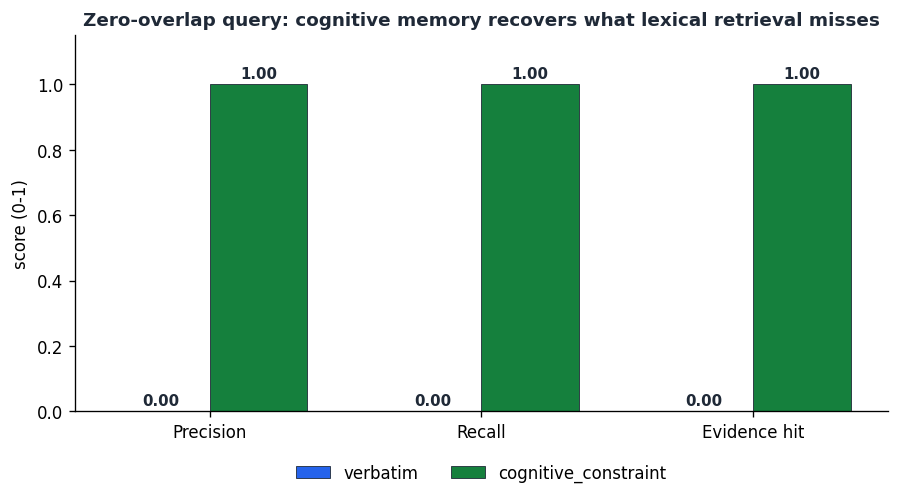

In [8]:
import matplotlib.pyplot as plt
import numpy as np

metrics   = ["Precision", "Recall", "Evidence hit"]
verbatim  = [0.0, 0.0, 0.0]   # lexical retrieval on a zero-overlap query -> total miss
cognitive = [1.0, 1.0, 1.0]   # constraint-aware read path -> evidence recovered

x = np.arange(len(metrics)); w = 0.36
fig, ax = plt.subplots(figsize=(7.6, 4.3), dpi=120)
b1 = ax.bar(x - w/2, verbatim,  w, label="verbatim",
            color="#2563EB", edgecolor="#1F2937", linewidth=0.5)
b2 = ax.bar(x + w/2, cognitive, w, label="cognitive_constraint",
            color="#15803D", edgecolor="#1F2937", linewidth=0.5)
for bars in (b1, b2):
    for r in bars:
        v = r.get_height()
        ax.text(r.get_x() + r.get_width()/2, v + 0.02, f"{v:.2f}",
                ha="center", weight="bold", fontsize=9, color="#1F2937")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15); ax.set_ylabel("score (0-1)")
ax.set_title("Zero-overlap query: cognitive memory recovers what lexical retrieval misses",
             color="#1F2937", weight="bold", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper center", ncol=2, bbox_to_anchor=(0.5, -0.10))
fig.tight_layout()
plt.show()

## Step 5 — the honest read: where CML-lite (and real CML) still fails

Apply the tutorial’s own diagnostic mindset to cognitive memory itself. CML-lite boosts
`evidence_hit` on constraint-bearing queries, but it is deliberately a sketch. Mapping our
gaps onto the **real CML repo’s LoCoMo-Plus results** (LLM-as-judge, 2,387 samples):

| LoCoMo-Plus question type | Real CML score | What’s missing in CML-lite |
|---|---|---|
| Adversarial (refuse to hallucinate) | **75.3%** (CML’s strength) | — |
| Overall | 48.6% | consolidation, forgetting, reconsolidation depth |
| Cognitive reasoning | 25.4% | no belief revision / conflict resolution |
| Multi-hop | 34.6% | no knowledge-graph / PageRank multi-path |
| Temporal | 35.5% | no time-aware decay or reconsolidation |

And the real CML README is candid about its own gaps — a model for how to *read* a memory
system critically: long-term stores are “currently write-only”; consolidation is
“inspired by replay, not an implementation of it”; the reconsolidation labile window is
“bookkeeping, not a delay”. **Diagnosis is the skill — even the system you admire has
failure modes you can name.**

## 💬 Q&A

**Q: Do I need an API key, GPU, or Docker for this notebook?**
A: The core (Steps 1-4) is pure Python and **runs offline — no key, no GPU, no Docker/Neo4j**. The
optional **Step 2b payoff demo** calls a live LLM, so it needs an API key (set in the config cell;
it degrades to a note if none). The real Cognitive Memory Layer needs Docker/Neo4j/~25 GB of models;
this notebook captures only its cognitive core so it fits a Colab slot.

**Q: Why does `verbatim` retrieve nothing while `cognitive_constraint` surfaces the allergy?**
A: Zero token overlap. "recommend a restaurant" shares no words with "allergic to shellfish", so the
cosine (token-overlap) score is ≈0 and lexical retrieval returns nothing. The cognitive read path
*injects* the relevant POLICY constraint independent of cosine — the whole point of constraint-aware memory.

**Q: How is the CAUSAL constraint a Phase-3 tie-in?**
A: In Phase 3 the autoresearch agent kept proposing OOM configs because raw history never generalised into
a *rule* (the gap between M1 raw-history and M3 structured-rule). Storing "depth 16 batch 32 → OOM" as a
CAUSAL constraint makes that rule first-class: any action/config query fires it, even with zero lexical
overlap (e.g. "is it safe to scale up our model size?"). Constraint memory *is* the M3 condition.

**Q: Is CML production-ready?**
A: The real CML is a research prototype (GPL-3.0, Docker + admin dashboard). For production, use Mem0
(managed) — or build just CML's constraint-extraction subset in pure Python, which is exactly what
`cognitive_constraint.py` is.

**Q: Will cognitive memory replace RAG?**
A: No — it's RAG *plus* cognitive layers. Vector retrieval is still there; constraint extraction and
constraint-aware surfacing are additions on top. Our 3-probe diagnostic showed the trade-off directly:
constraints fix recall on zero-overlap queries but can dilute precision on richer corpora (a Probe-1 risk).

**Q: Where does CML-lite fall short of the real CML?**
A: It omits the 15 memory types & biological decay, reconsolidation (REINFORCE / TIME_SLICE / MERGE /
ADD_HYPOTHESIS), consolidation, active-forgetting triage, and multi-path retrieval (vector + KG PageRank +
rescoring). Mapping these gaps onto CML's own LoCoMo-Plus weak spots (cognitive reasoning 25.4%, multi-hop
34.6%, temporal 35.5%) is the "diagnose a cognitive system" exercise in Step 5 above.

Guidance: use this notebook in Phase 4 (0:25–0:40) to show (1) constraint extraction at
write time, (2) the cognitive read path beating plain RAG on zero overlap, (3) the Phase-3
CAUSAL tie-in, and (4) the precision↔recall trade-off exposed by our own 3-probe diagnostic.
Then frame the honest read as the bridge to the real CML repo and its LoCoMo-Plus profile.